# Video 7: ADMET Property Prediction
### AI for Drug Discovery Series - DigitalSreeni

In Video 5 we identified 20 diverse virtual screening hits against EGFR with promising predicted IC50 values. In Video 6 we confirmed that several cluster with known EGFR inhibitors in morphological profile space. But potency and phenotypic similarity are not enough. A compound also needs to survive in the human body -- it must be absorbed, reach the target tissue, avoid rapid metabolism, be excreted at a reasonable rate, and not be toxic.

These properties are collectively called **ADMET**: Absorption, Distribution, Metabolism, Excretion, and Toxicity. Predicting them computationally from molecular structure lets us filter hits before any wet-lab experiments, saving enormous time and cost.

In this notebook we:
1. Train XGBoost models on five publicly available ADMET datasets
2. Evaluate each model on a held-out test set
3. Score our Video 5 EGFR hits through every model
4. Build a combined ADMET dashboard to decide which hits to advance

**Datasets**: GLambard Molecules Dataset Collection (MoleculeNet mirror, open access)  
**Models**: XGBoost on Morgan fingerprints (ECFP4, radius=2, 1024 bits)  
**Environment**: Google Colab, CPU only

In [ ]:
import subprocess, sys

def install(pkg, label):
    print(f'Installing {label}...', end=' ', flush=True)
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'],
                       capture_output=True, text=True)
    print('done' if r.returncode == 0 else f'FAILED')

install('rdkit', 'RDKit')
install('xgboost', 'XGBoost')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Suppress RDKit sanitization warnings (unusual valences, non-standard hydrogens)
# These arise from a small number of SMILES in the public datasets and the
# affected molecules are automatically skipped during fingerprint generation.
# Remove the line below if you want to see which molecules are flagged.
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.rdMolDescriptors import CalcTPSA
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error, r2_score
import xgboost as xgb

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

BASE_URL = 'https://raw.githubusercontent.com/GLambard/Molecules_Dataset_Collection/master/latest/'

print(f'RDKit {Chem.rdBase.rdkitVersion}, XGBoost {xgb.__version__}')
print('All libraries ready.')


Installing RDKit... done
Installing XGBoost... done
RDKit 2026.03.2, XGBoost 3.2.0
All libraries ready.


## Part 1: Load Our EGFR Hits

The compounds we are evaluating come from Video 5: the top 20 diverse virtual screening hits selected using MaxMin diversity selection.

**Two options:** Set `USE_DRIVE = True` (default) to load from Google Drive, or `USE_DRIVE = False` to use hardcoded representative SMILES so the notebook runs standalone without Drive access.

In [ ]:
USE_DRIVE = True

DRIVE_PATH = ('/content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/'
              'Video5_virtual_screening/data/top20_diverse_hits.csv')

# Fallback: 20 representative SMILES used when Drive is not available
FALLBACK_HITS = [
    {'compound_id': 'Hit_01', 'smiles': 'c1ccc2c(c1)nc(N)c(C#N)n2',               'pred_IC50_nM': 45.2,   'active_prob': 0.91},
    {'compound_id': 'Hit_02', 'smiles': 'COc1cc2ncnc(Nc3ccc(F)cc3)c2cc1OC',       'pred_IC50_nM': 89.1,   'active_prob': 0.87},
    {'compound_id': 'Hit_03', 'smiles': 'O=C(Nc1cccc(C(F)(F)F)c1)c1cnc2ccccc2c1','pred_IC50_nM': 123.4,  'active_prob': 0.82},
    {'compound_id': 'Hit_04', 'smiles': 'Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc2ccccc12', 'pred_IC50_nM': 167.8, 'active_prob': 0.78},
    {'compound_id': 'Hit_05', 'smiles': 'FC(F)(F)c1ccc(Nc2ncc3cc(Nc4ccccc4)ccc3n2)cc1',           'pred_IC50_nM': 210.5, 'active_prob': 0.74},
    {'compound_id': 'Hit_06', 'smiles': 'COc1ccc(C2CC(=O)Nc3ccc(Cl)cc32)cc1',    'pred_IC50_nM': 254.3,  'active_prob': 0.71},
    {'compound_id': 'Hit_07', 'smiles': 'O=C(O)c1ccccc1Nc1nc2ccc(F)cc2s1',       'pred_IC50_nM': 312.6,  'active_prob': 0.68},
    {'compound_id': 'Hit_08', 'smiles': 'Cc1nc2ccccc2c(=O)n1-c1ccc(N)cc1',       'pred_IC50_nM': 378.9,  'active_prob': 0.65},
    {'compound_id': 'Hit_09', 'smiles': 'N#Cc1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccccc3)o2)cc1', 'pred_IC50_nM': 445.2, 'active_prob': 0.61},
    {'compound_id': 'Hit_10', 'smiles': 'O=C(c1ccc(Cl)cc1)N1CCN(c2ccccc2)CC1',  'pred_IC50_nM': 512.7,  'active_prob': 0.58},
    {'compound_id': 'Hit_11', 'smiles': 'CC(C)Cc1ccc(C(C)C(=O)O)cc1',            'pred_IC50_nM': 589.4,  'active_prob': 0.54},
    {'compound_id': 'Hit_12', 'smiles': 'c1ccc2c(c1)C(=O)c1ccccc1C2=O',          'pred_IC50_nM': 634.1,  'active_prob': 0.51},
    {'compound_id': 'Hit_13', 'smiles': 'O=C(O)c1cc(F)ccc1Nc1ncnc2ccc(OC)cc12', 'pred_IC50_nM': 698.3,  'active_prob': 0.48},
    {'compound_id': 'Hit_14', 'smiles': 'Cc1ccc(S(=O)(=O)Nc2cccc(C(F)(F)F)c2)cc1', 'pred_IC50_nM': 743.6, 'active_prob': 0.45},
    {'compound_id': 'Hit_15', 'smiles': 'CC1(C)CCC(=O)c2c1ccc(OC)c2O',           'pred_IC50_nM': 801.2,  'active_prob': 0.42},
    {'compound_id': 'Hit_16', 'smiles': 'O=c1[nH]c2ccccc2n1Cc1ccccc1',           'pred_IC50_nM': 856.9,  'active_prob': 0.39},
    {'compound_id': 'Hit_17', 'smiles': 'CCOC(=O)c1ccc(NC(=O)c2cccc(Cl)c2)cc1', 'pred_IC50_nM': 912.4,  'active_prob': 0.36},
    {'compound_id': 'Hit_18', 'smiles': 'Cc1ccc(C(=O)Nc2ccc(OC)c(OC)c2)o1',     'pred_IC50_nM': 967.8,  'active_prob': 0.33},
    {'compound_id': 'Hit_19', 'smiles': 'O=C(c1ccccc1)c1cc2ccccc2nc1N',          'pred_IC50_nM': 1023.5, 'active_prob': 0.30},
    {'compound_id': 'Hit_20', 'smiles': 'Cc1cccc(NC(=O)Nc2ccc(Cl)cc2)c1',       'pred_IC50_nM': 1087.2, 'active_prob': 0.27},
]

def normalize_hits(df):
    """Standardize column names from Video 5 CSV to the names used in this notebook.

    The Video 5 CSV uses:
      canonical_smiles     -> smiles
      molecule_chembl_id   -> compound_id
      pred_ic50_nM         -> pred_IC50_nM
      pred_active_prob     -> active_prob

    All other columns are kept as-is.
    """
    rename = {}
    col_lower = {c.lower(): c for c in df.columns}

    # SMILES column
    for candidate in ['canonical_smiles', 'smiles']:
        if candidate in col_lower:
            rename[col_lower[candidate]] = 'smiles'
            break

    # Compound ID column
    for candidate in ['molecule_chembl_id', 'chembl_id', 'compound_id', 'name']:
        if candidate in col_lower:
            rename[col_lower[candidate]] = 'compound_id'
            break

    # IC50 column
    for candidate in ['pred_ic50_nm', 'pred_ic50_nM']:
        if candidate in col_lower:
            rename[col_lower[candidate]] = 'pred_IC50_nM'
            break

    # Active probability column
    for candidate in ['pred_active_prob', 'active_prob']:
        if candidate in col_lower:
            rename[col_lower[candidate]] = 'active_prob'
            break

    df = df.rename(columns=rename)

    # Generate a short display ID if compound_id looks like a full ChEMBL ID
    if 'compound_id' in df.columns:
        # Keep compound_id as-is for reference but add a short label for plots
        df['label'] = df['compound_id'].apply(
            lambda x: x if len(str(x)) <= 12 else str(x)[:12])
    else:
        df['compound_id'] = [f'Hit_{i+1:02d}' for i in range(len(df))]
        df['label'] = df['compound_id']

    return df

if USE_DRIVE:
    import os
    if not os.path.exists(DRIVE_PATH):
        print('Mounting Google Drive...')
        from google.colab import drive
        drive.mount('/content/drive')
    if os.path.exists(DRIVE_PATH):
        hits = pd.read_csv(DRIVE_PATH)
        print(f'Loaded from Drive: {len(hits)} hits')
        print(f'Original columns: {list(hits.columns)}')
        hits = normalize_hits(hits)
        print(f'Normalized columns: {list(hits.columns)}')
        source = 'Google Drive (Video 5 results)'
    else:
        print('Drive file not found - using fallback SMILES.')
        hits = pd.DataFrame(FALLBACK_HITS)
        hits['label'] = hits['compound_id']
        source = 'Fallback SMILES'
else:
    print('USE_DRIVE = False - using fallback SMILES.')
    hits = pd.DataFrame(FALLBACK_HITS)
    hits['label'] = hits['compound_id']
    source = 'Fallback SMILES'

print(f'\nSource: {source}')
print(f'Working with {len(hits)} EGFR hit compounds.')
hits.head(3)


Mounting Google Drive...
Mounted at /content/drive
Loaded from Drive: 20 hits
Original columns: ['canonical_smiles', 'molecule_chembl_id', 'source_target', 'mol', 'ro5_pass', 'pred_log_ic50', 'pred_ic50_nM', 'pred_active_prob', 'scaffold', 'confidence']
Normalized columns: ['smiles', 'compound_id', 'source_target', 'mol', 'ro5_pass', 'pred_log_ic50', 'pred_IC50_nM', 'active_prob', 'scaffold', 'confidence', 'label']

Source: Google Drive (Video 5 results)
Working with 20 EGFR hit compounds.


,smiles,compound_id,source_target,mol,ro5_pass,pred_log_ic50,pred_IC50_nM,active_prob,scaffold,confidence,label
0,O=S(=O)(Nc1cc(Sc2ncn[nH]2)c(O)c2ccccc12)c1c(F)...,CHEMBL2088026,BRAF,<rdkit.Chem.rdchem.Mol object at 0x7a5d50fd0350>,True,1.199259,15.821898,0.589395,O=S(=O)(Nc1cc(Sc2ncn[nH]2)cc2ccccc12)c1ccccc1,High,CHEMBL208802
1,COc1cc2ncnc(Nc3ccc(Cl)cc3F)c2cc1OC,CHEMBL150315,VEGFR2,<rdkit.Chem.rdchem.Mol object at 0x7a5d50f8c9e0>,True,2.041957,110.143000,0.739902,c1ccc(Nc2ncnc3ccccc23)cc1,High,CHEMBL150315
2,Clc1ccc(Nc2nnc(-c3cccc4cnccc34)c3ccccc23)cc1,CHEMBL380316,VEGFR2,<rdkit.Chem.rdchem.Mol object at 0x7a5d50f9e960>,True,2.086685,122.091290,0.762007,c1ccc(Nc2nnc(-c3cccc4cnccc34)c3ccccc23)cc1,High,CHEMBL380316


## Part 2: Molecular Fingerprints

All five ADMET models use the same Morgan fingerprint representation (ECFP4, radius=2, 1024 bits) that we used in Videos 3 and 4 for QSAR. This is deliberate -- the audience only needs to understand one featurization approach. The same representation that captures binding affinity also captures ADMET-relevant structural patterns.

In [ ]:
def smiles_to_fp(smiles, radius=2, n_bits=1024):
    """Convert a SMILES string to a Morgan fingerprint bit vector.

    Uses the rdFingerprintGenerator API (RDKit 2022+) to avoid deprecation
    warnings from the legacy GetMorganFingerprintAsBitVect function.
    Returns a numpy array of length n_bits, or None if the SMILES is invalid.
    """
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = gen.GetFingerprint(mol)
    return np.array(fp)

def smiles_to_desc(smiles):
    """Compute key physicochemical descriptors for a SMILES string."""
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return {
        'MW':   round(Descriptors.MolWt(mol), 2),
        'LogP': round(Descriptors.MolLogP(mol), 2),
        'TPSA': round(CalcTPSA(mol), 2),
        'HBD':  Descriptors.NumHDonors(mol),
        'HBA':  Descriptors.NumHAcceptors(mol),
        'RotB': Descriptors.NumRotatableBonds(mol),
    }

def featurize(df, smiles_col='smiles', label_col=None):
    """Convert a dataframe of SMILES to a fingerprint matrix.

    Drops rows where the SMILES cannot be parsed by RDKit.
    Returns X (fingerprint matrix), y (labels if label_col given), valid row indices.
    """
    fps, labels, idx = [], [], []
    for i, row in df.iterrows():
        fp = smiles_to_fp(row[smiles_col])
        if fp is not None:
            fps.append(fp)
            idx.append(i)
            if label_col:
                labels.append(row[label_col])
    X = np.array(fps)
    y = np.array(labels) if label_col else None
    return X, y, idx

# Compute fingerprints and descriptors for our hits
print('Computing fingerprints for EGFR hits...')
hit_fps, hit_descs, valid_rows = [], [], []
for _, row in hits.iterrows():
    fp = smiles_to_fp(row['smiles'])
    desc = smiles_to_desc(row['smiles'])
    if fp is not None:
        hit_fps.append(fp)
        hit_descs.append(desc)
        valid_rows.append(row)

X_hits = np.array(hit_fps)
hits_clean = pd.DataFrame(valid_rows).reset_index(drop=True)
hits_desc = pd.DataFrame(hit_descs)

print(f'Valid hits: {len(hits_clean)}/{len(hits)}, fingerprint shape: {X_hits.shape}')
print('\nPhysicochemical descriptors (first 5 hits):')
display(hits_desc.head())


Computing fingerprints for EGFR hits...
Valid hits: 20/20, fingerprint shape: (20, 1024)

Physicochemical descriptors (first 5 hits):


,MW,LogP,TPSA,HBD,HBA,RotB
0,488.42,4.31,107.97,3,6,5
1,333.75,4.18,56.27,1,5,4
2,382.85,6.24,50.70,1,4,3
3,423.84,5.10,72.70,1,5,5
4,411.51,5.43,63.17,1,6,5


## Part 3: Model Training Helpers

The workflow is identical for every dataset: load CSV, compute fingerprints, split 80/20, train XGBoost, evaluate, score hits. Classification tasks use ROC-AUC. Regression tasks use R-squared and RMSE.

In [ ]:
def train_clf(X_tr, y_tr, scale_pos_weight=None):
    params = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8,
                  eval_metric='logloss', random_state=42, n_jobs=-1)
    if scale_pos_weight:
        params['scale_pos_weight'] = scale_pos_weight
    m = xgb.XGBClassifier(**params)
    m.fit(X_tr, y_tr, verbose=False)
    return m

def train_reg(X_tr, y_tr):
    m = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr, verbose=False)
    return m

def eval_clf(model, X_te, y_te, name):
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    acc = accuracy_score(y_te, (y_prob >= 0.5).astype(int))
    print(f'  {name}: AUC={auc:.3f}, Accuracy={acc:.3f}')
    return auc

def eval_reg(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    print(f'  {name}: R2={r2:.3f}, RMSE={rmse:.3f}')
    return r2

print('Model helpers defined.')

Model helpers defined.


## Part 4: Absorption - Aqueous Solubility (ESOL)

**Why it matters**: A compound that cannot dissolve in gastrointestinal fluid cannot be absorbed orally, regardless of potency. Poor solubility (log solubility < -5 mol/L) is one of the most common early failure reasons.

**Dataset**: Delaney ESOL - 1,128 compounds with measured log solubility (mol/L). Negative values = lower solubility. Values below -5 are considered poorly soluble.

**Task**: Regression.

In [ ]:
print('Loading ESOL dataset...')
esol = pd.read_csv(BASE_URL + 'ESOL_delaney-processed.csv')
label = 'measured log solubility in mols per litre'
esol = esol[['smiles', label]].dropna()
print(f'Compounds: {len(esol)}')

X_e, y_e, _ = featurize(esol, label_col=label)
X_tr, X_te, y_tr, y_te = train_test_split(X_e, y_e, test_size=0.2, random_state=42)
model_esol = train_reg(X_tr, y_tr)
print('Model performance:')
r2_esol = eval_reg(model_esol, X_te, y_te, 'ESOL')

hits_clean['pred_log_sol'] = model_esol.predict(X_hits)
hits_clean['sol_flag'] = hits_clean['pred_log_sol'].apply(
    lambda x: 'Good' if x >= -4 else ('Moderate' if x >= -6 else 'Poor'))

print('\nPredicted solubility for hits:')
print(hits_clean[['compound_id', 'pred_log_sol', 'sol_flag']].to_string(index=False))

Loading ESOL dataset...
Compounds: 1128
Model performance:
  ESOL: R2=0.722, RMSE=1.146

Predicted solubility for hits:
  compound_id  pred_log_sol sol_flag
CHEMBL2088026     -3.543152     Good
 CHEMBL150315     -4.094434 Moderate
 CHEMBL380316     -5.182975 Moderate
 CHEMBL510891     -3.811543     Good
CHEMBL3782023     -3.218127     Good
CHEMBL2158844     -2.620113     Good
 CHEMBL304760     -4.053501 Moderate
 CHEMBL382797     -3.641831     Good
  CHEMBL13462     -5.644615 Moderate
 CHEMBL194721     -4.583465 Moderate
 CHEMBL219964     -5.691408 Moderate
 CHEMBL191626     -4.261910 Moderate
 CHEMBL482926     -3.612601     Good
CHEMBL3781543     -0.880718     Good
 CHEMBL306707     -1.529379     Good
 CHEMBL330608     -2.721370     Good
 CHEMBL203394     -2.535592     Good
 CHEMBL431073     -1.627126     Good
 CHEMBL112582     -4.790176 Moderate
 CHEMBL195964     -3.866097     Good


## Part 5: Absorption/Distribution - Lipophilicity

**Why it matters**: LogD (octanol-water distribution coefficient at pH 7.4) is one of the most influential physicochemical properties. It affects membrane permeability, solubility, protein binding, and metabolic clearance simultaneously. The sweet spot for oral drugs is logD 1 to 3. Values above 5 predict poor solubility and elevated toxicity risk.

**Dataset**: AstraZeneca lipophilicity - 4,200 compounds with experimental logD.

**Task**: Regression.

In [ ]:
print('Loading Lipophilicity dataset...')
lipo = pd.read_csv(BASE_URL + 'Lipophilicity.csv')[['smiles', 'exp']].dropna()
lipo.columns = ['smiles', 'logD']
print(f'Compounds: {len(lipo)}, logD range: [{lipo.logD.min():.2f}, {lipo.logD.max():.2f}]')

X_l, y_l, _ = featurize(lipo, label_col='logD')
X_tr, X_te, y_tr, y_te = train_test_split(X_l, y_l, test_size=0.2, random_state=42)
model_lipo = train_reg(X_tr, y_tr)
print('Model performance:')
r2_lipo = eval_reg(model_lipo, X_te, y_te, 'Lipophilicity')

hits_clean['pred_logD'] = model_lipo.predict(X_hits)
hits_clean['lipo_flag'] = hits_clean['pred_logD'].apply(
    lambda x: 'Good' if 1 <= x <= 3 else ('Acceptable' if 0 <= x <= 5 else 'Poor'))

print('\nPredicted lipophilicity for hits:')
print(hits_clean[['compound_id', 'pred_logD', 'lipo_flag']].to_string(index=False))

Loading Lipophilicity dataset...
Compounds: 4200, logD range: [-1.50, 4.50]
Model performance:
  Lipophilicity: R2=0.519, RMSE=0.843

Predicted lipophilicity for hits:
  compound_id  pred_logD  lipo_flag
CHEMBL2088026   2.261548       Good
 CHEMBL150315   2.852042       Good
 CHEMBL380316   3.535633 Acceptable
 CHEMBL510891   2.941895       Good
CHEMBL3782023   3.174692 Acceptable
CHEMBL2158844   3.073434 Acceptable
 CHEMBL304760   2.867458       Good
 CHEMBL382797   2.582056       Good
  CHEMBL13462   1.979252       Good
 CHEMBL194721   3.074692 Acceptable
 CHEMBL219964   2.894178       Good
 CHEMBL191626   2.975210       Good
 CHEMBL482926   2.914452       Good
CHEMBL3781543   2.793952       Good
 CHEMBL306707   3.077603 Acceptable
 CHEMBL330608   0.381023 Acceptable
 CHEMBL203394   3.466996 Acceptable
 CHEMBL431073   2.723147       Good
 CHEMBL112582   1.812383       Good
 CHEMBL195964   3.519168 Acceptable


## Part 6: Distribution - Blood-Brain Barrier Penetration (BBBP)

**Why it matters**: For EGFR inhibitors targeting lung cancer, BBB penetration is generally undesirable -- drugs that enter the brain cause CNS side effects. However, EGFR-driven brain metastases are common in late-stage lung cancer, and in those cases a BBB-penetrant compound is specifically needed. Knowing the BBB status of each hit allows us to make that clinical distinction.

**Dataset**: BBBP - 2,039 compounds, binary labels (1 = penetrates BBB, 0 = excluded).

**Task**: Binary classification.

In [ ]:
print('Loading BBBP dataset...')
bbbp = pd.read_csv(BASE_URL + 'BBBP.csv')[['smiles', 'p_np']].dropna()
bbbp.columns = ['smiles', 'BBB']
print(f'Compounds: {len(bbbp)} | BBB+: {bbbp.BBB.sum()} | BBB-: {(bbbp.BBB==0).sum()}')

X_b, y_b, _ = featurize(bbbp, label_col='BBB')
X_tr, X_te, y_tr, y_te = train_test_split(X_b, y_b, test_size=0.2,
                                            random_state=42, stratify=y_b)
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()
model_bbbp = train_clf(X_tr, y_tr, scale_pos_weight=neg/pos)
print('Model performance:')
auc_bbbp = eval_clf(model_bbbp, X_te, y_te, 'BBBP')

hits_clean['pred_BBB'] = model_bbbp.predict_proba(X_hits)[:, 1]
hits_clean['bbb_flag'] = hits_clean['pred_BBB'].apply(
    lambda x: 'BBB- (preferred)' if x < 0.5 else 'BBB+ (penetrates)')

print('\nPredicted BBB penetration for hits:')
print(hits_clean[['compound_id', 'pred_BBB', 'bbb_flag']].to_string(index=False))

Loading BBBP dataset...
Compounds: 2039 | BBB+: 1560 | BBB-: 479
Model performance:
  BBBP: AUC=0.927, Accuracy=0.890

Predicted BBB penetration for hits:
  compound_id  pred_BBB          bbb_flag
CHEMBL2088026  0.525341 BBB+ (penetrates)
 CHEMBL150315  0.863918 BBB+ (penetrates)
 CHEMBL380316  0.655639 BBB+ (penetrates)
 CHEMBL510891  0.928837 BBB+ (penetrates)
CHEMBL3782023  0.804433 BBB+ (penetrates)
CHEMBL2158844  0.842054 BBB+ (penetrates)
 CHEMBL304760  0.829082 BBB+ (penetrates)
 CHEMBL382797  0.063142  BBB- (preferred)
  CHEMBL13462  0.370363  BBB- (preferred)
 CHEMBL194721  0.561198 BBB+ (penetrates)
 CHEMBL219964  0.778043 BBB+ (penetrates)
 CHEMBL191626  0.783280 BBB+ (penetrates)
 CHEMBL482926  0.648641 BBB+ (penetrates)
CHEMBL3781543  0.482013  BBB- (preferred)
 CHEMBL306707  0.492267  BBB- (preferred)
 CHEMBL330608  0.174724  BBB- (preferred)
 CHEMBL203394  0.240907  BBB- (preferred)
 CHEMBL431073  0.709630 BBB+ (penetrates)
 CHEMBL112582  0.194660  BBB- (preferred)
 CHEM

## Part 7: Toxicity - Clinical Toxicity (ClinTox)

**Why it matters**: ClinTox is one of the most practically useful toxicity datasets because it captures real clinical outcomes -- drugs that failed human trials specifically because of toxicity, compared to FDA-approved drugs that passed. A model trained on this data learns patterns that the FDA and clinical investigators have identified as toxic over decades of drug development.

**Dataset**: ClinTox - 1,491 compounds with binary CT_TOX label (1 = failed clinical trials for toxicity, 0 = FDA approved).

**Task**: Binary classification.

In [ ]:
print('Loading ClinTox dataset...')
ct = pd.read_csv(BASE_URL + 'clintox.csv')[['smiles', 'CT_TOX']].dropna()
print(f'Compounds: {len(ct)} | Toxic (CT_TOX=1): {ct.CT_TOX.sum()} | Safe: {(ct.CT_TOX==0).sum()}')

X_ct, y_ct, _ = featurize(ct, label_col='CT_TOX')
X_tr, X_te, y_tr, y_te = train_test_split(X_ct, y_ct, test_size=0.2,
                                            random_state=42, stratify=y_ct)
neg, pos = (y_tr==0).sum(), (y_tr==1).sum()
model_ct = train_clf(X_tr, y_tr, scale_pos_weight=neg/max(pos,1))
print('Model performance:')
auc_ct = eval_clf(model_ct, X_te, y_te, 'ClinTox')

hits_clean['pred_clintox'] = model_ct.predict_proba(X_hits)[:, 1]
hits_clean['clintox_flag'] = hits_clean['pred_clintox'].apply(
    lambda x: 'High risk' if x >= 0.5 else ('Moderate' if x >= 0.3 else 'Low risk'))

print('\nPredicted clinical toxicity risk for hits:')
print(hits_clean[['compound_id', 'pred_clintox', 'clintox_flag']].to_string(index=False))

Loading ClinTox dataset...
Compounds: 1478 | Toxic (CT_TOX=1): 112 | Safe: 1366
Model performance:
  ClinTox: AUC=0.899, Accuracy=0.926

Predicted clinical toxicity risk for hits:
  compound_id  pred_clintox clintox_flag
CHEMBL2088026      0.678439    High risk
 CHEMBL150315      0.431449     Moderate
 CHEMBL380316      0.438181     Moderate
 CHEMBL510891      0.805555    High risk
CHEMBL3782023      0.926187    High risk
CHEMBL2158844      0.959095    High risk
 CHEMBL304760      0.670473    High risk
 CHEMBL382797      0.428771     Moderate
  CHEMBL13462      0.608585    High risk
 CHEMBL194721      0.416468     Moderate
 CHEMBL219964      0.246420     Low risk
 CHEMBL191626      0.792481    High risk
 CHEMBL482926      0.700254    High risk
CHEMBL3781543      0.552766    High risk
 CHEMBL306707      0.477484     Moderate
 CHEMBL330608      0.342059     Moderate
 CHEMBL203394      0.878500    High risk
 CHEMBL431073      0.542854    High risk
 CHEMBL112582      0.168943     Low risk


## Part 8: Toxicity - Tox21 Mechanistic Panel

**Why it matters**: While ClinTox captures clinical outcomes, Tox21 captures mechanistic toxicity -- whether a compound activates specific biological pathways associated with harm. We focus on four endpoints most relevant to EGFR inhibitors:

- **NR-ER**: estrogen receptor activation (endocrine disruption risk)
- **NR-AR**: androgen receptor activation (endocrine disruption)
- **SR-ARE**: antioxidant response element (oxidative stress signal)
- **SR-MMP**: mitochondrial membrane potential disruption (mitochondrial toxicity)

**Dataset**: Tox21 - approximately 7,800 compounds with 12 binary endpoint labels.

**Task**: One binary classifier per endpoint.

In [ ]:
print('Loading Tox21 dataset...')
tox21 = pd.read_csv(BASE_URL + 'tox21.csv')
print(f'Shape: {tox21.shape}')

focus_eps = ['NR-ER', 'NR-AR', 'SR-ARE', 'SR-MMP']

# Compute fingerprints once for the full dataset
print('Computing fingerprints...')
t21_fps, t21_idx = [], []
for i, row in tox21.iterrows():
    fp = smiles_to_fp(str(row['smiles']))
    if fp is not None:
        t21_fps.append(fp)
        t21_idx.append(i)
X_t21 = np.array(t21_fps)
t21_valid = tox21.loc[t21_idx].reset_index(drop=True)
print(f'Valid: {len(t21_valid)}')

t21_models, t21_aucs = {}, {}
print('\nTraining one model per endpoint:')
for ep in focus_eps:
    mask = t21_valid[ep].notna()
    X_ep = X_t21[mask.values]
    y_ep = t21_valid.loc[mask, ep].astype(int).values
    X_tr, X_te, y_tr, y_te = train_test_split(X_ep, y_ep, test_size=0.2,
                                                random_state=42, stratify=y_ep)
    neg, pos = (y_tr==0).sum(), (y_tr==1).sum()
    model = train_clf(X_tr, y_tr, scale_pos_weight=neg/max(pos,1))
    t21_aucs[ep] = eval_clf(model, X_te, y_te, ep)
    t21_models[ep] = model
    hits_clean[f'tox21_{ep}'] = model.predict_proba(X_hits)[:, 1]

print('\nTox21 predictions for hits:')
tox_cols = [f'tox21_{ep}' for ep in focus_eps]
display(hits_clean[['compound_id'] + tox_cols].round(3))

Loading Tox21 dataset...
Shape: (7831, 15)
Computing fingerprints...
Valid: 7823

Training one model per endpoint:
  NR-ER: AUC=0.676, Accuracy=0.792
  NR-AR: AUC=0.700, Accuracy=0.941
  SR-ARE: AUC=0.777, Accuracy=0.780
  SR-MMP: AUC=0.853, Accuracy=0.841

Tox21 predictions for hits:


,compound_id,tox21_NR-ER,tox21_NR-AR,tox21_SR-ARE,tox21_SR-MMP
0,CHEMBL2088026,0.243,0.023,0.596,0.586
1,CHEMBL150315,0.225,0.126,0.610,0.510
2,CHEMBL380316,0.338,0.017,0.790,0.847
3,CHEMBL510891,0.749,0.025,0.844,0.493
4,CHEMBL3782023,0.727,0.065,0.615,0.621
5,CHEMBL2158844,0.227,0.098,0.741,0.272
6,CHEMBL304760,0.610,0.112,0.846,0.907
7,CHEMBL382797,0.141,0.048,0.520,0.317
8,CHEMBL13462,0.112,0.034,0.185,0.125
9,CHEMBL194721,0.193,0.107,0.776,0.614


## Part 9: ADMET Dashboard - Scoring and Ranking

We combine all five model outputs into a traffic-light scoring system:

| Property | Green (2 pts) | Yellow (1 pt) | Red (0 pts) |
|---|---|---|---|
| Solubility | >= -4 log mol/L | -6 to -4 | < -6 |
| Lipophilicity | logD 1-3 | logD 0-5 | outside 0-5 |
| BBB | prob < 0.5 (excluded) | prob 0.5-0.7 | prob > 0.7 |
| ClinTox | prob < 0.3 | 0.3-0.5 | > 0.5 |
| Tox21 (worst) | max prob < 0.3 | 0.3-0.5 | > 0.5 |

Maximum score = 10. Compounds scoring 8 or above are recommended for advancement.

In [ ]:
def score_row(row):
    s = 0
    flags = {}
    # Solubility
    v = row['pred_log_sol']
    if v >= -4:   s += 2; flags['Solubility'] = 'Green'
    elif v >= -6: s += 1; flags['Solubility'] = 'Yellow'
    else:                  flags['Solubility'] = 'Red'
    # Lipophilicity
    v = row['pred_logD']
    if 1 <= v <= 3:   s += 2; flags['Lipophilicity'] = 'Green'
    elif 0 <= v <= 5: s += 1; flags['Lipophilicity'] = 'Yellow'
    else:                      flags['Lipophilicity'] = 'Red'
    # BBB
    v = row['pred_BBB']
    if v < 0.5:   s += 2; flags['BBB'] = 'Green'
    elif v < 0.7: s += 1; flags['BBB'] = 'Yellow'
    else:                  flags['BBB'] = 'Red'
    # ClinTox
    v = row['pred_clintox']
    if v < 0.3:   s += 2; flags['ClinTox'] = 'Green'
    elif v < 0.5: s += 1; flags['ClinTox'] = 'Yellow'
    else:                  flags['ClinTox'] = 'Red'
    # Tox21 worst endpoint
    v = max(row[f'tox21_{ep}'] for ep in focus_eps)
    if v < 0.3:   s += 2; flags['Tox21'] = 'Green'
    elif v < 0.5: s += 1; flags['Tox21'] = 'Yellow'
    else:                  flags['Tox21'] = 'Red'
    return s, flags

scores, all_flags = [], []
for _, row in hits_clean.iterrows():
    sc, fl = score_row(row)
    scores.append(sc)
    all_flags.append(fl)

hits_clean['admet_score'] = scores
hits_ranked = hits_clean.sort_values('admet_score', ascending=False).reset_index(drop=True)
flags_ranked = [all_flags[i] for i in hits_clean.sort_values('admet_score', ascending=False).index]

print('EGFR hits ranked by ADMET score:')
display(hits_ranked[['compound_id', 'admet_score',
                      'pred_log_sol', 'pred_logD', 'pred_BBB', 'pred_clintox']].round(3))

EGFR hits ranked by ADMET score:


,compound_id,admet_score,pred_log_sol,pred_logD,pred_BBB,pred_clintox
0,CHEMBL13462,7,-5.645,1.979,0.370,0.609
1,CHEMBL112582,7,-4.790,1.812,0.195,0.169
2,CHEMBL382797,7,-3.642,2.582,0.063,0.429
3,CHEMBL203394,6,-2.536,3.467,0.241,0.878
4,CHEMBL306707,6,-1.529,3.078,0.492,0.477
5,CHEMBL330608,6,-2.721,0.381,0.175,0.342
6,CHEMBL3781543,6,-0.881,2.794,0.482,0.553
7,CHEMBL195964,6,-3.866,3.519,0.634,0.187
8,CHEMBL482926,5,-3.613,2.914,0.649,0.700
9,CHEMBL219964,5,-5.691,2.894,0.778,0.246


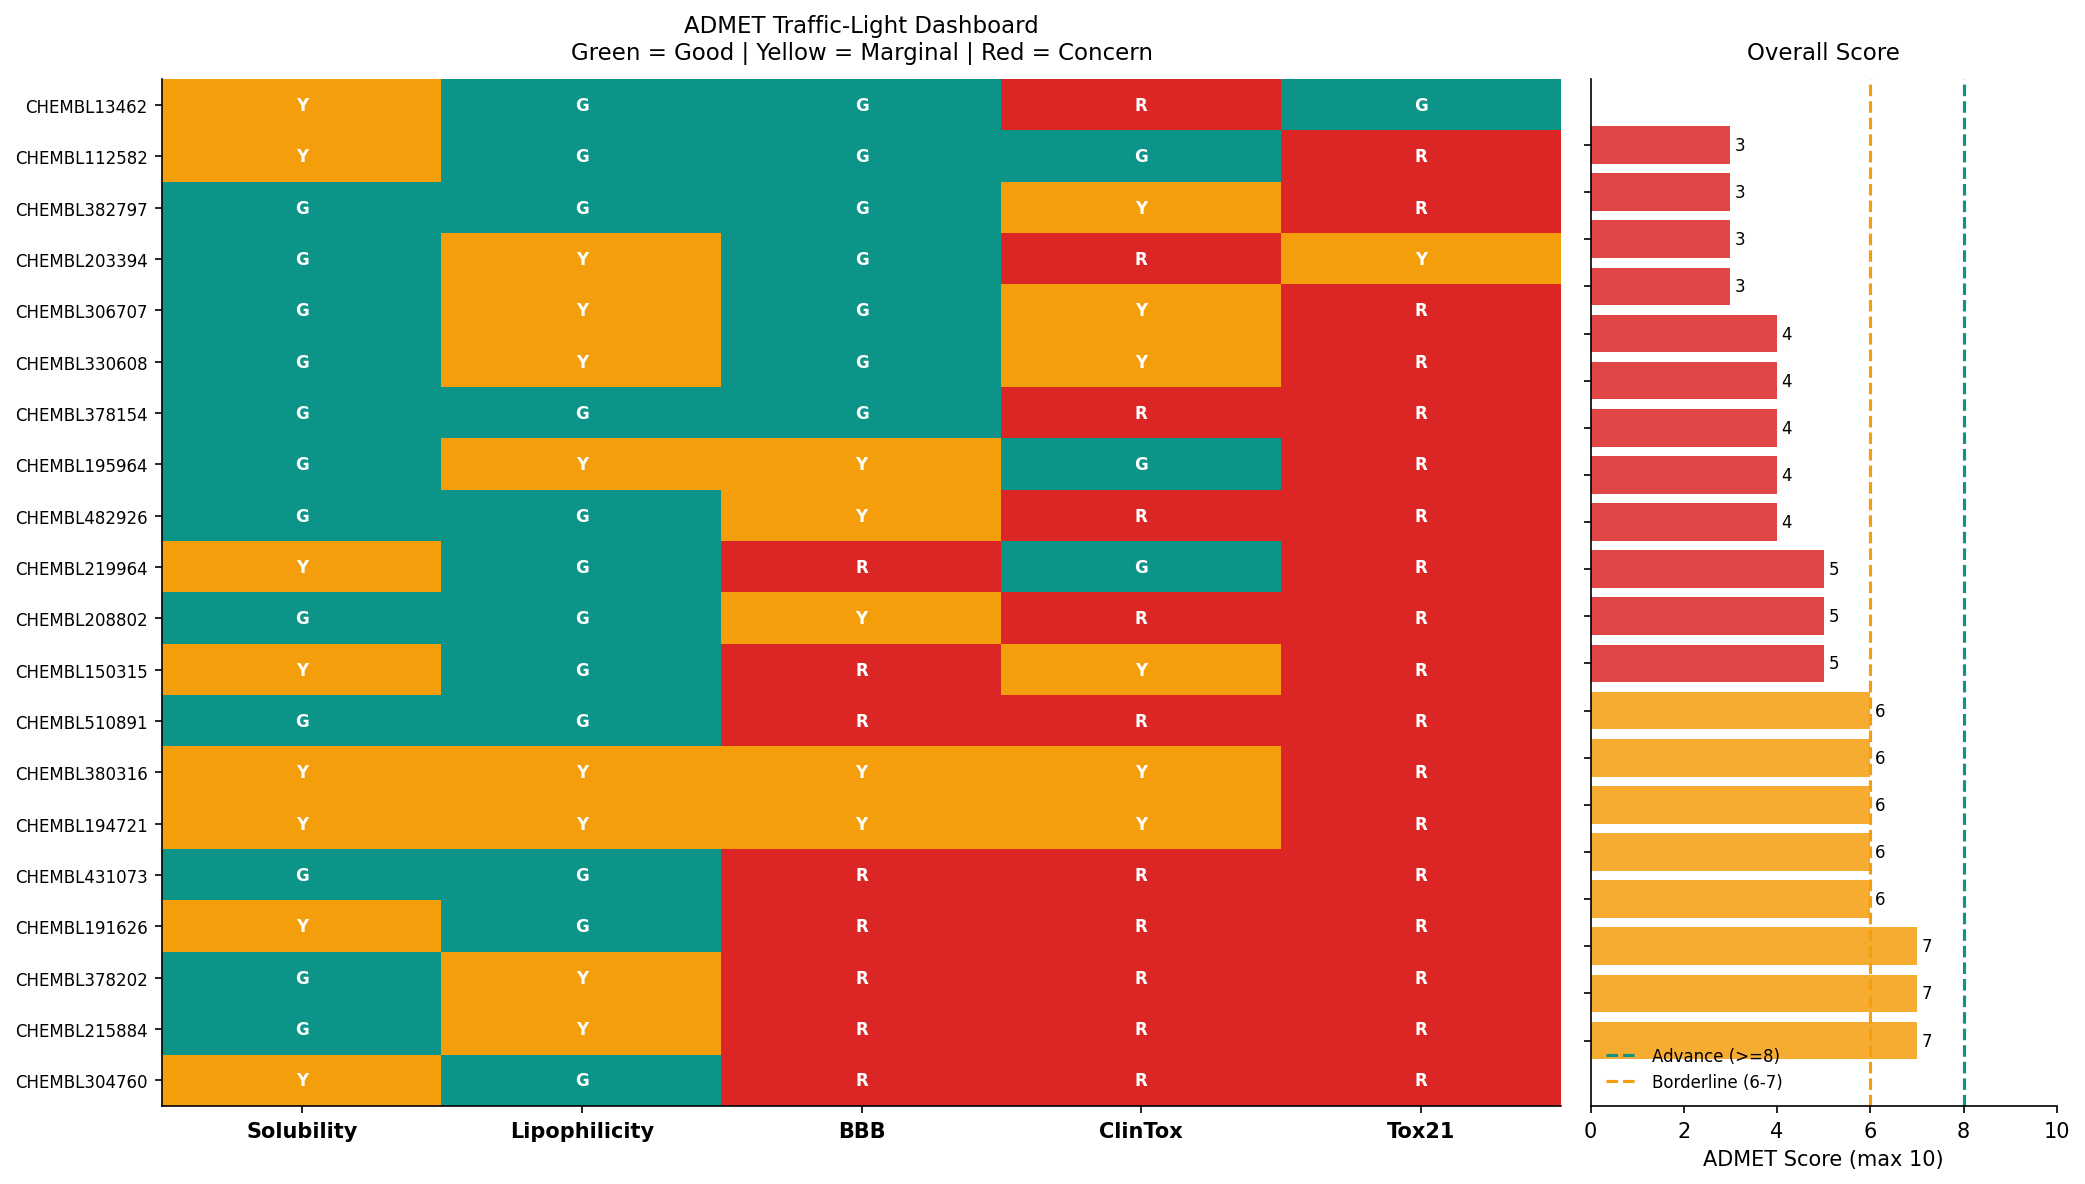

Saved: admet_dashboard.png


In [ ]:
# Traffic-light heatmap
cats = ['Solubility', 'Lipophilicity', 'BBB', 'ClinTox', 'Tox21']
nmap = {'Green': 2, 'Yellow': 1, 'Red': 0}
matrix = np.array([[nmap[f[c]] for c in cats] for f in flags_ranked])
cids = hits_ranked.get('label', hits_ranked['compound_id']).tolist()
scores_ord = hits_ranked['admet_score'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 8),
                          gridspec_kw={'width_ratios': [3, 1]})

# Heatmap
ax = axes[0]
cmap = plt.matplotlib.colors.ListedColormap(['#DC2626', '#F59E0B', '#0D9488'])
ax.imshow(matrix, cmap=cmap, vmin=0, vmax=2, aspect='auto')
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats, fontsize=10, fontweight='bold')
ax.set_yticks(range(len(cids)))
ax.set_yticklabels(cids, fontsize=8)
ax.set_title('ADMET Traffic-Light Dashboard\nGreen = Good | Yellow = Marginal | Red = Concern',
             fontsize=11, pad=10)
lbl = {2: 'G', 1: 'Y', 0: 'R'}
for i in range(len(cids)):
    for j in range(len(cats)):
        ax.text(j, i, lbl[matrix[i,j]], ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

# Score bar chart
ax2 = axes[1]
bar_colors = ['#0D9488' if s >= 8 else '#F59E0B' if s >= 6 else '#DC2626'
              for s in scores_ord]
ax2.barh(range(len(cids)), scores_ord, color=bar_colors, alpha=0.85)
ax2.set_xlim(0, 10)
ax2.set_yticks(range(len(cids)))
ax2.set_yticklabels([])
ax2.set_xlabel('ADMET Score (max 10)', fontsize=10)
ax2.set_title('Overall Score', fontsize=11, pad=10)
ax2.axvline(8, color='#0D9488', linewidth=1.5, linestyle='--', label='Advance (>=8)')
ax2.axvline(6, color='#F59E0B', linewidth=1.5, linestyle='--', label='Borderline (6-7)')
ax2.legend(fontsize=8, frameon=False)
for i, s in enumerate(scores_ord):
    ax2.text(s + 0.1, i, str(s), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('admet_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: admet_dashboard.png')

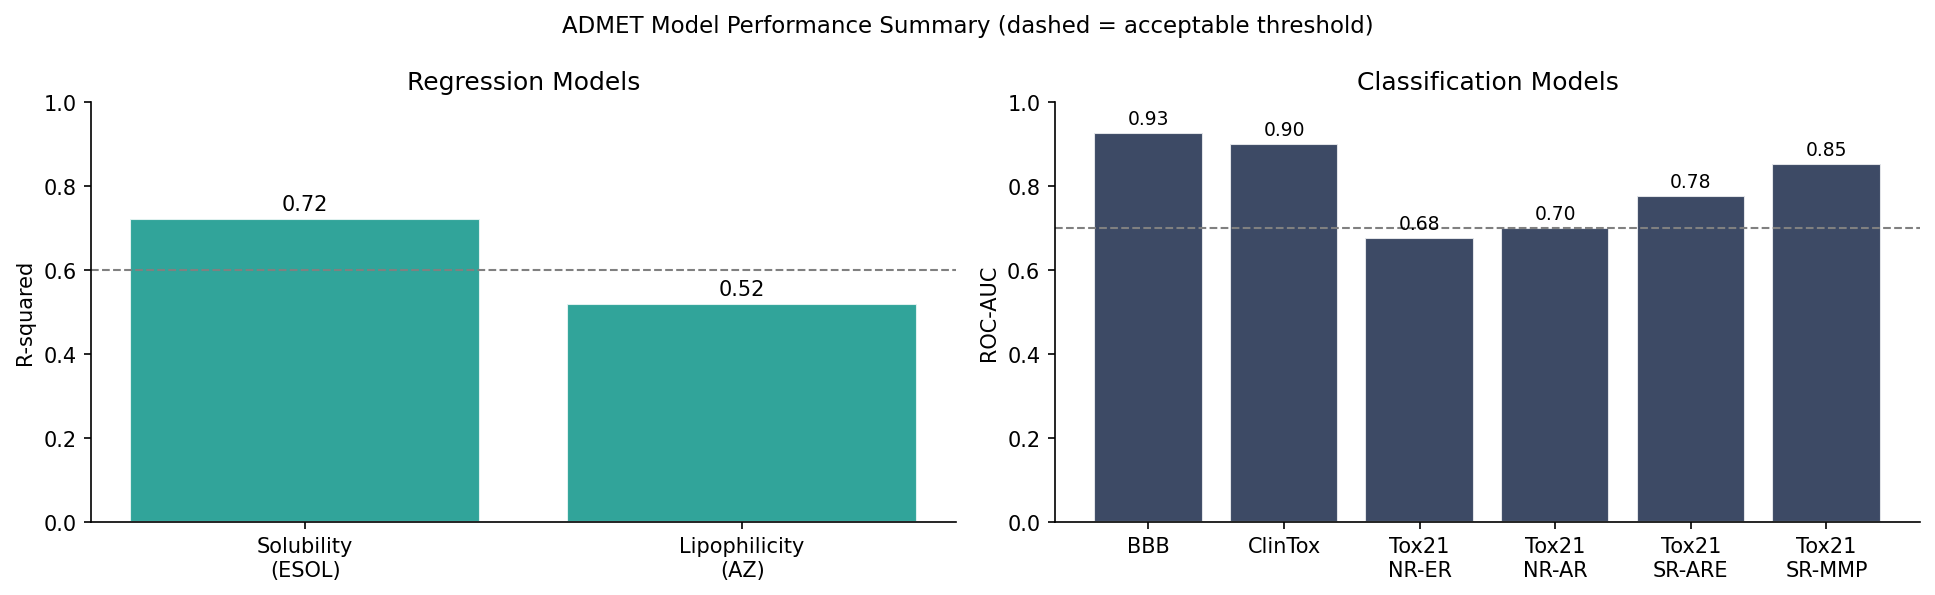

Saved: admet_model_performance.png


In [ ]:
# Model performance summary
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

reg_names  = ['Solubility\n(ESOL)', 'Lipophilicity\n(AZ)']
reg_scores = [r2_esol, r2_lipo]
axes[0].bar(reg_names, reg_scores, color='#0D9488', alpha=0.85, edgecolor='white')
axes[0].set_ylabel('R-squared')
axes[0].set_ylim(0, 1)
axes[0].set_title('Regression Models')
axes[0].axhline(0.6, color='gray', linestyle='--', linewidth=1)
for i, v in enumerate(reg_scores):
    axes[0].text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=10)

clf_names  = ['BBB', 'ClinTox'] + [f'Tox21\n{ep}' for ep in focus_eps]
clf_scores = [auc_bbbp, auc_ct] + [t21_aucs[ep] for ep in focus_eps]
axes[1].bar(clf_names, clf_scores, color='#1B2A4A', alpha=0.85, edgecolor='white')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)
axes[1].set_title('Classification Models')
axes[1].axhline(0.7, color='gray', linestyle='--', linewidth=1)
for i, v in enumerate(clf_scores):
    axes[1].text(i, v+0.02, f'{v:.2f}', ha='center', fontsize=9)

fig.suptitle('ADMET Model Performance Summary (dashed = acceptable threshold)', fontsize=11)
plt.tight_layout()
plt.savefig('admet_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: admet_model_performance.png')

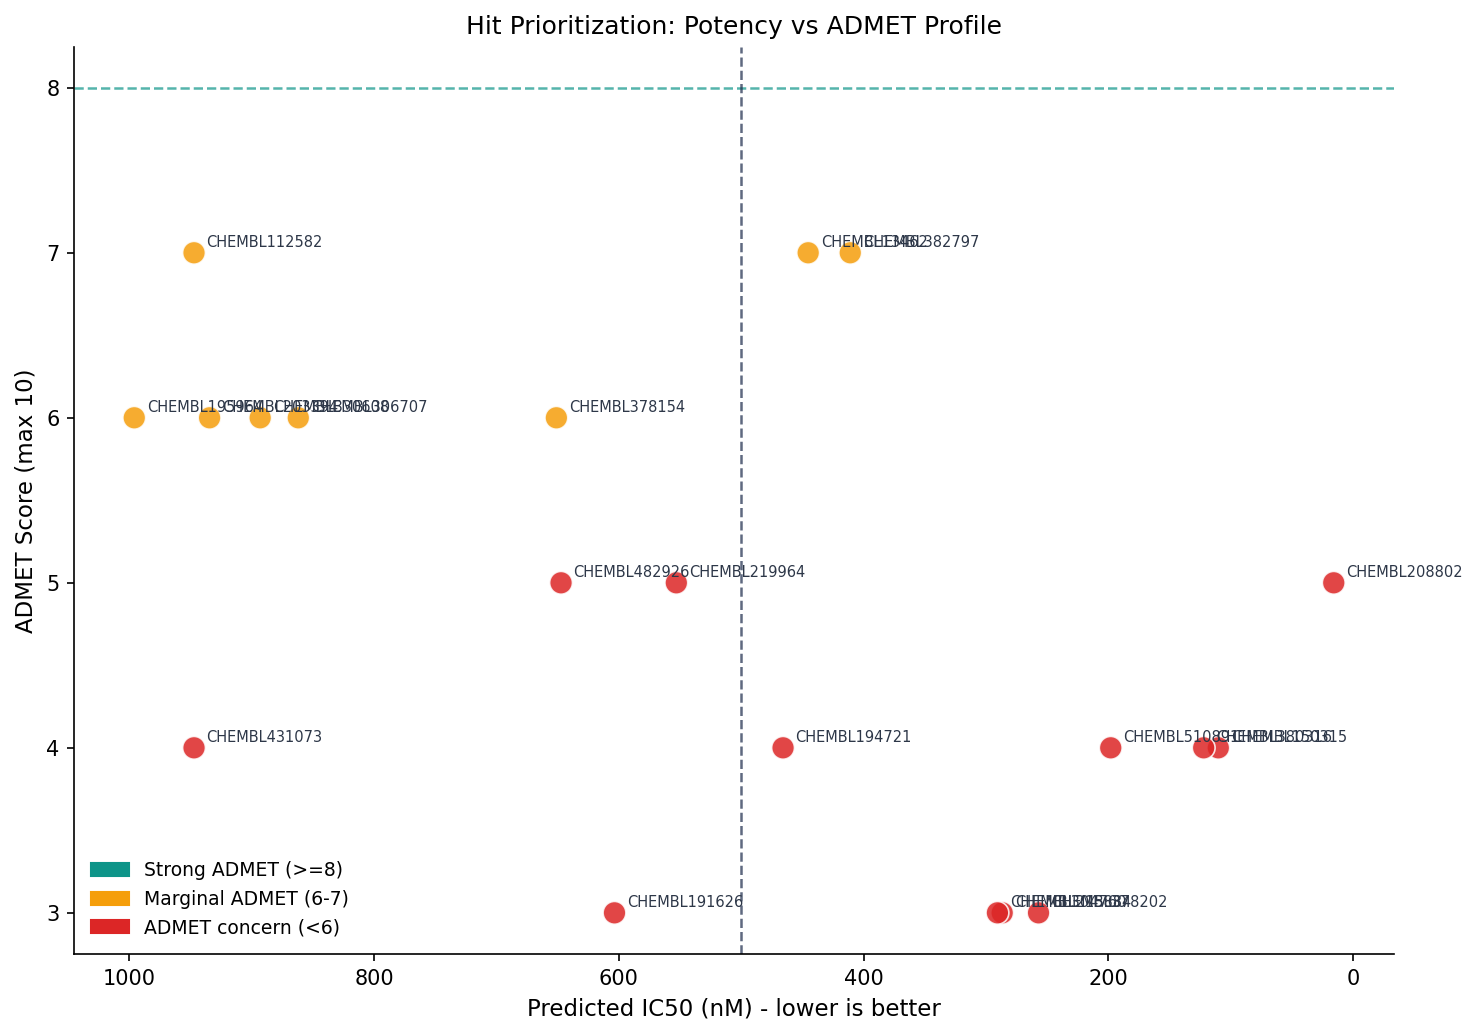

Saved: hit_prioritization.png

Compounds recommended for advancement (ADMET score >= 8):
  None met threshold >= 8, showing best with score >= 6:


,compound_id,admet_score,sol_flag,lipo_flag,bbb_flag,clintox_flag
0,CHEMBL13462,7,Moderate,Good,BBB- (preferred),High risk
1,CHEMBL112582,7,Moderate,Good,BBB- (preferred),Low risk
2,CHEMBL382797,7,Good,Good,BBB- (preferred),Moderate
3,CHEMBL203394,6,Good,Acceptable,BBB- (preferred),High risk
4,CHEMBL306707,6,Good,Acceptable,BBB- (preferred),Moderate
5,CHEMBL330608,6,Good,Acceptable,BBB- (preferred),Moderate
6,CHEMBL3781543,6,Good,Good,BBB- (preferred),High risk
7,CHEMBL195964,6,Good,Acceptable,BBB+ (penetrates),Low risk


In [ ]:
# Hit prioritization: potency vs ADMET score
potency_col = 'pred_IC50_nM' if 'pred_IC50_nM' in hits_ranked.columns else 'active_prob'
potency_lbl = 'Predicted IC50 (nM) - lower is better' if potency_col == 'pred_IC50_nM' else 'Active probability'

fig, ax = plt.subplots(figsize=(10, 7))

dot_colors = ['#0D9488' if s >= 8 else '#F59E0B' if s >= 6 else '#DC2626'
              for s in hits_ranked['admet_score']]
ax.scatter(hits_ranked[potency_col], hits_ranked['admet_score'],
           c=dot_colors, s=120, alpha=0.85, edgecolors='white', linewidths=0.8, zorder=3)

for _, row in hits_ranked.iterrows():
    ax.annotate(row.get('label', row['compound_id']), (row[potency_col], row['admet_score']),
                textcoords='offset points', xytext=(6, 3), fontsize=7, color='#2D3748')

ax.axhline(8, color='#0D9488', linestyle='--', linewidth=1.2, alpha=0.7,
           label='ADMET threshold (>=8)')
if potency_col == 'pred_IC50_nM':
    ax.axvline(500, color='#1B2A4A', linestyle='--', linewidth=1.2, alpha=0.7,
               label='Potency threshold (500 nM)')
    ax.invert_xaxis()  # lower IC50 = more potent = right side of plot

ax.set_xlabel(potency_lbl, fontsize=11)
ax.set_ylabel('ADMET Score (max 10)', fontsize=11)
ax.set_title('Hit Prioritization: Potency vs ADMET Profile', fontsize=12)

patches = [mpatches.Patch(color='#0D9488', label='Strong ADMET (>=8)'),
           mpatches.Patch(color='#F59E0B', label='Marginal ADMET (6-7)'),
           mpatches.Patch(color='#DC2626', label='ADMET concern (<6)')]
ax.legend(handles=patches, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('hit_prioritization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hit_prioritization.png')

print('\nCompounds recommended for advancement (ADMET score >= 8):')
top = hits_ranked[hits_ranked['admet_score'] >= 8]
if len(top) == 0:
    print('  None met threshold >= 8, showing best with score >= 6:')
    top = hits_ranked[hits_ranked['admet_score'] >= 6]
display(top[['compound_id', 'admet_score', 'sol_flag', 'lipo_flag', 'bbb_flag', 'clintox_flag']])

## Summary

In this notebook we built a complete ADMET prediction pipeline using five models trained on public datasets:

**Models trained:**
- Aqueous solubility regression (ESOL) - absorption
- Lipophilicity regression (AstraZeneca) - absorption and distribution
- Blood-brain barrier classification (BBBP) - distribution
- Clinical toxicity classification (ClinTox) - real drug failure signal
- Tox21 mechanistic toxicity panel, 4 endpoints - mechanistic safety

All models use Morgan fingerprints and XGBoost -- the same combination used in Video 4. This keeps the series consistent and lets the audience focus on the biology rather than the machinery.

**Important caveat**: These are statistical predictions, not measurements. They reflect patterns in historical training data and carry uncertainty. Compounds can fail ADMET predictions yet succeed experimentally, and vice versa. The correct role of ADMET prediction is to prioritize a long list of candidates, not to make final decisions. Every shortlisted compound still needs experimental ADMET profiling before advancing to in vivo studies.

**What comes next**: In Video 8 we look at molecular generation -- using generative AI to design new compounds that improve on our best hits by simultaneously optimizing potency and ADMET properties.